In [29]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [27]:
data = pd.read_csv("banking.csv")

In [28]:
data.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y
0,44,blue-collar,married,basic.4y,unknown,yes,no,cellular,aug,thu,...,1,999,0,nonexistent,1.4,93.444,-36.1,4.963,5228.1,0
1,53,technician,married,unknown,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.021,5195.8,0
2,28,management,single,university.degree,no,yes,no,cellular,jun,thu,...,3,6,2,success,-1.7,94.055,-39.8,0.729,4991.6,1
3,39,services,married,high.school,no,no,no,cellular,apr,fri,...,2,999,0,nonexistent,-1.8,93.075,-47.1,1.405,5099.1,0
4,55,retired,married,basic.4y,no,yes,no,cellular,aug,fri,...,1,3,1,success,-2.9,92.201,-31.4,0.869,5076.2,1


<Axes: >

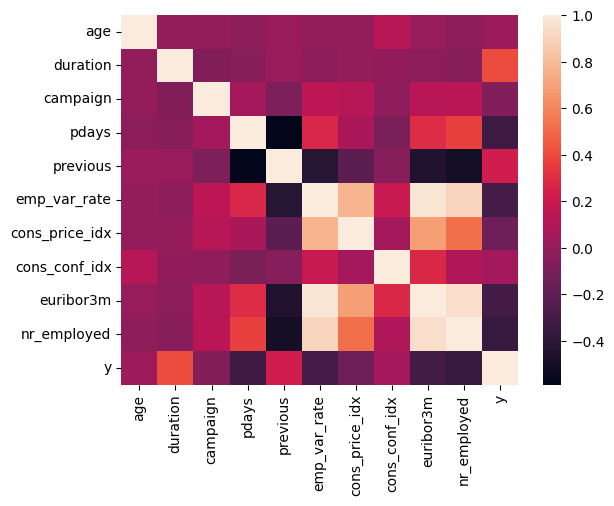

In [21]:
# The error when I used data.corr() directly is because the dataset contains categorical (string) values like 'blue-collar', and data.corr() only works on numeric columns.
corre = data.corr(numeric_only=True)
sns.heatmap(corre)

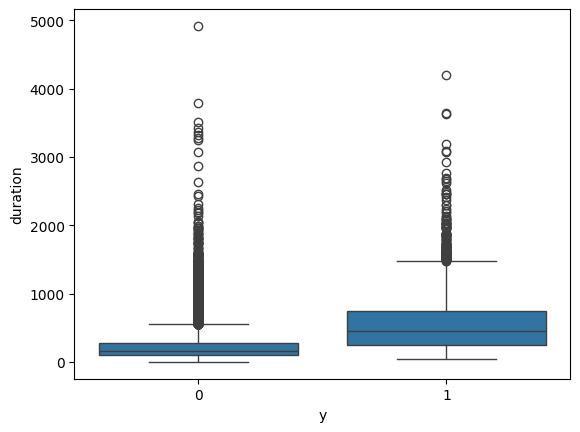

In [30]:
sns.boxplot(x="y", y="duration", data = data)
plt.show()

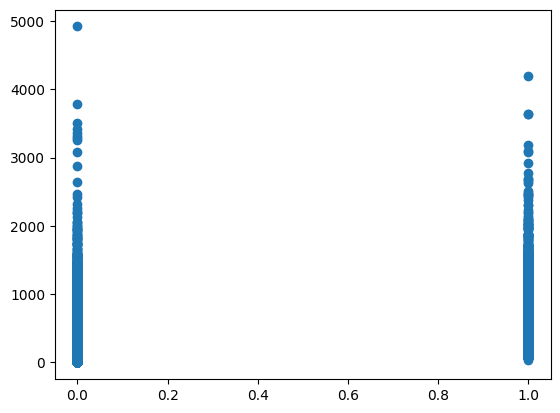

In [31]:
plt.scatter(data['y'], data['duration'])

In [33]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
data["encoded"] = encoder.fit_transform(data["marital"])
data[['age', 'encoded']].head()

,age,encoded
0,44,1
1,53,1
2,28,2
3,39,1
4,55,1


In [35]:
data['marital'].value_counts()

marital
married     24928
single      11568
divorced     4612
unknown        80
Name: count, dtype: int64

In [34]:
data['encoded'].value_counts()

encoded
1    24928
2    11568
0     4612
3       80
Name: count, dtype: int64

In [39]:
data['loan'].value_counts()

loan
no         33950
yes         6248
unknown      990
Name: count, dtype: int64

In [45]:
data['y'].value_counts()

y
0    36548
1     4640
Name: count, dtype: int64

In [51]:
y = data["y"]
x = data[['age', 'pdays', 'previous', 'emp_var_rate', 'cons_price_idx', 'encoded']]

In [52]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)
from sklearn.preprocessing import StandardScaler
scaling = StandardScaler()
scaling.fit(x_train)

StandardScaler()

In [53]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(x_train, y_train)
model.score(x_train, y_train)

/Users/atulkumar/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.8970257966616085

In [54]:
model.coef_

array([[ 0.00799171, -0.00220491, -0.13927999, -0.48515997, -0.00744663,
         0.14364383]])

In [57]:
from sklearn.pipeline import make_pipeline
test = []
for lam in np.arange(0.01, 100, 0.1):
    pipe = make_pipeline(StandardScaler(), LogisticRegression(C=1/lam))
    pipe.fit(x_train, y_train)
    scores = pipe.score(x_test, y_test)
    test.append(scores)

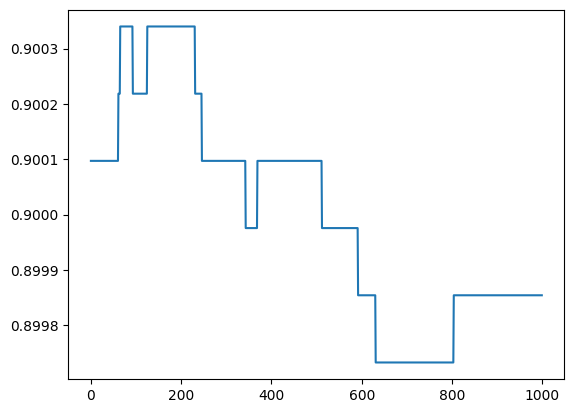

In [59]:
plt.plot(test)

In [60]:
np.argmax(test)

65

In [62]:
lam_best = 0.01*65*0.1